# Objective
The objective of this assessment is to apply unsupervised machine learning techniques, specifically clustering algorithms, to analyze patterns within the Iris dataset. The task involves preprocessing the dataset by removing labeled information and implementing clustering methods such as KMeans clustering and Hierarchical clustering to group similar data points based on their features.

The goal is to understand how these algorithms identify natural groupings in data, compare their performance, and visualize the resulting clusters to gain meaningful insights from an unlabeled dataset.

In [37]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [23]:
iris = load_iris()

In [24]:
# Convert to DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

In [25]:
# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [26]:
# Convert back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

In [39]:
scaled_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),KMeans_Cluster,HC_Cluster
0,-0.900681,1.019004,-1.340227,-1.315444,1,1
1,-1.143017,-0.131979,-1.340227,-1.315444,2,1
2,-1.385353,0.328414,-1.397064,-1.315444,2,1
3,-1.506521,0.098217,-1.283389,-1.315444,2,1
4,-1.021849,1.249201,-1.340227,-1.315444,1,1


## How KMeans Works

KMeans clustering works as follows:

- Choose number of clusters (K)
- Randomly initialize centroids
- Assign each point to nearest centroid
- Recalculate centroids
- Repeat until convergence
##  Why KMeans is Suitable for Iris
- Iris data is numerical and well-separated
- Contains clear natural groupings (3 clusters)
- Works well with spherical cluster shapes

In [28]:
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_df)

In [42]:
# Add cluster labels
scaled_df['KMeans_Cluster'] = kmeans_labels

print(scaled_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   
3          -1.506521          0.098217          -1.283389         -1.315444   
4          -1.021849          1.249201          -1.340227         -1.315444   

   KMeans_Cluster  HC_Cluster  
0               1           1  
1               2           1  
2               2           1  
3               2           1  
4               1           1  


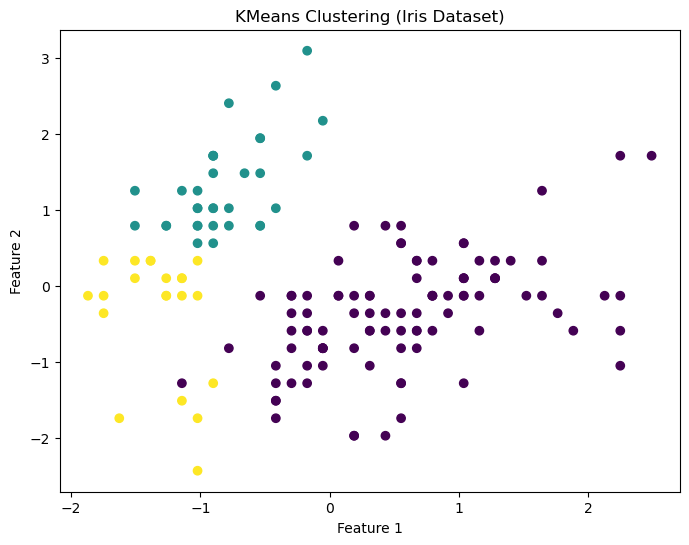

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_df.iloc[:, 0], 
    scaled_df.iloc[:, 1], 
    c=kmeans_labels, 
    cmap='viridis'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clustering (Iris Dataset)')
plt.show()

## Key Insights from the Chart
- The data is grouped into 3 distinct clusters, which aligns with the expected structure of the Iris dataset.
- One cluster (purple) is clearly separated on the right side, indicating a group with significantly different feature values.
- The other two clusters (yellow and green) are closer to each other, showing some overlap and similarity between those data points.
- The cluster in the top-left region (green) has higher Feature 2 values, suggesting a distinct pattern in that dimension.
- The bottom-left cluster (yellow) has lower Feature 2 values, making it visually separable from the top cluster.
- Overall, KMeans has successfully identified natural groupings, but slight overlap indicates that some data points are not perfectly separable.

## How Hierarchical Clustering Works

Hierarchical clustering works in two ways:

### Agglomerative (bottom-up):

- Each point starts as its own cluster
- Closest clusters are merged step-by-step

### Divisive (top-down):

- Start with one cluster and split
- It produces a dendrogram (tree structure).

## Why Hierarchical Clustering is Suitable for Iris
- No need to predefine number of clusters initially
- Helps visualize cluster relationships via dendrogram
- Works well for small datasets like Iris

In [43]:
# Apply model
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(scaled_df.iloc[:, :-1])

# Add labels
scaled_df['HC_Cluster'] = hc_labels

print(scaled_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   
3          -1.506521          0.098217          -1.283389         -1.315444   
4          -1.021849          1.249201          -1.340227         -1.315444   

   KMeans_Cluster  HC_Cluster  
0               1           0  
1               2           0  
2               2           0  
3               2           0  
4               1           0  


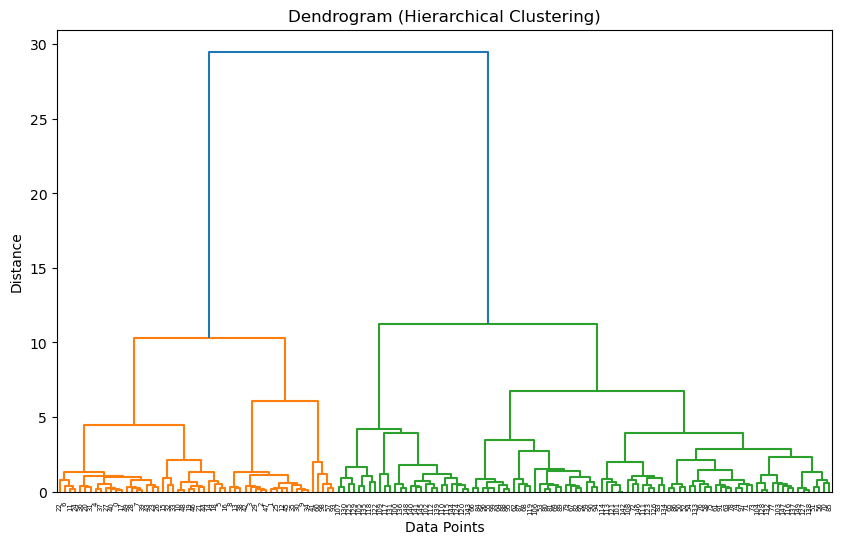

In [36]:
linked = linkage(scaled_df.iloc[:, :-1], method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

## Key Insights from the Dendrogram
- The dendrogram shows 3 main clusters, which can be identified by drawing a horizontal cut around distance ≈ 10–12.
- One cluster (left side) is well separated, merging with others only at a much higher distance (~30), indicating strong dissimilarity.
- The other two clusters (right side) are closer to each other, merging at a lower distance, which shows they are more similar.
- The height of the vertical lines represents distance (dissimilarity) — larger heights indicate more distinct clusters.
- The gradual merging of smaller branches at lower distances shows high similarity among nearby data points within clusters.
- Overall, the dendrogram confirms that the dataset naturally forms distinct groupings, with one clearly different cluster and two relatively similar clusters.

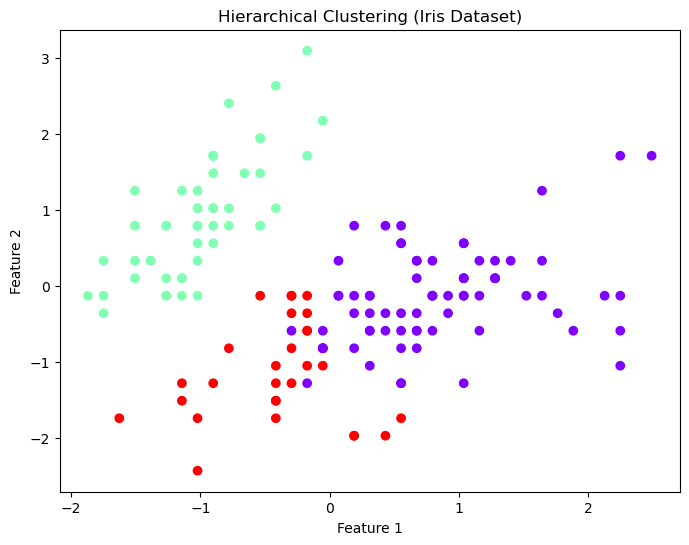

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_df.iloc[:, 0], 
    scaled_df.iloc[:, 1], 
    c=hc_labels, 
    cmap='rainbow'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Hierarchical Clustering (Iris Dataset)')
plt.show()

## Key Insights
- The data is grouped into 3 clusters, indicating clear natural grouping in the Iris dataset.
- The green cluster (top-left) is well separated, showing a group with distinct feature values.
- The purple cluster (right side) is more spread out, indicating higher variation within that cluster.
- The red cluster (bottom) is closer to the purple cluster, suggesting some similarity between them.
- There is slight overlap between red and purple clusters, meaning some data points are not clearly separable.
- Feature 2 plays a key role in separation, as clusters are visually divided along the vertical axis.
- Overall, hierarchical clustering successfully identifies structure, but shows minor overlap in similar regions.

## Conclusion 
In this project, clustering techniques were applied to the Iris dataset to identify natural groupings without using labels. Both KMeans clustering and Hierarchical clustering successfully formed three clusters, closely matching the dataset’s inherent structure.
KMeans provided efficient and clear clustering, while Hierarchical clustering offered better insight into relationships between data points. Overall, both methods effectively revealed patterns, with minor overlap between some clusters.